# 📊 Promotional Campaign Performance Analysis

This notebook analyzes retail promotional campaign data across stores, products, and cities.
It covers data quality checks, cleaning, exploratory analysis, campaign-level comparisons, and visual summaries.

**Datasets used:**
- `dim_campaigns.csv` — campaign metadata
- `dim_stores.csv` — store & city information
- `dim_products.csv` — product & category information
- `fact_events.csv` — sales quantities and prices before/after promotions

---

## 1. Data Overview

### 1.1 Campaigns Data
A quick look at the campaigns table to understand what campaigns exist.

In [3]:
import pandas as pd
df = pd.read_csv('dim_campaigns.csv')
df.head()

,campaign_id,campaign_name,start_date,end_date
0,CAMP_DIW_01,Diwali,12-11-2023,18-11-2023
1,CAMP_SAN_01,Sankranti,10-01-2024,16-01-2024


### 1.2 Checking for Duplicate Records in Events Data

Before analyzing sales, we check whether the `fact_events` table has duplicate rows (same store, campaign, and product appearing more than once).

In [4]:
import pandas as pd
events = pd.read_csv('fact_events.csv')

# Just typing the expression (last line) auto-displays as a nice table
events.duplicated(subset=['store_id', 'campaign_id', 'product_code']).sum()


np.int64(10)

In [5]:
duplicates = events[events.duplicated(subset=['store_id', 'campaign_id', 'product_code'], keep=False)]
duplicates.sort_values(['store_id', 'campaign_id', 'product_code'])

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo)
126,4ad12b,STBLR-4,CAMP_DIW_01,P15,3000,407.0,500 Cashback,2500,1245
1003,4ad12b,STBLR-4,CAMP_DIW_01,P15,3000,407.0,500 Cashback,2500,1245
40,46d57b,STBLR-9,CAMP_DIW_01,P13,350,94.0,BOGOF,175,329
74,46d57b,STBLR-9,CAMP_DIW_01,P13,350,94.0,BOGOF,175,329
738,5c7b20,STCBE-4,CAMP_DIW_01,P05,55,101.0,25% OFF,41,89
1313,5c7b20,STCBE-4,CAMP_DIW_01,P05,55,101.0,25% OFF,41,89
905,d622c3,STHYD-0,CAMP_SAN_01,P10,50,25.0,25% OFF,37,20
1401,d622c3,STHYD-0,CAMP_SAN_01,P10,50,25.0,25% OFF,37,20
395,6.24E+11,STMLR-0,CAMP_SAN_01,P03,200,206.0,BOGOF,100,541
541,6.24E+11,STMLR-0,CAMP_SAN_01,P03,200,206.0,BOGOF,100,541


---
## 2. Store Network Overview

### 2.1 Number of Stores per City

In [6]:
import pandas as pd

stores = pd.read_csv('dim_stores.csv')
store_counts = stores.groupby('city')['store_id'].nunique().sort_values(ascending=False)
store_counts 

city
Bengaluru        10
Chennai           8
Hyderabad         7
Coimbatore        5
Visakhapatnam     5
Madurai           4
Mysuru            4
Mangalore         3
Trivandrum        2
Vijayawada        2
Name: store_id, dtype: int64

### 2.2 Cities with More Than 5 Stores
Identifying cities that have a larger store presence (more than 5 stores).

In [7]:
cities_gt5 = store_counts[store_counts > 5]
cities_gt5

city
Bengaluru    10
Chennai       8
Hyderabad     7
Name: store_id, dtype: int64

---
## 3. Data Cleaning

### 3.1 Handling Missing Values
The `quantity_sold(before_promo)` column has some missing values. We fill them with the column median so later aggregations aren't skewed.

In [8]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
missing_values_count = events['quantity_sold(before_promo)'].isnull().sum()

median_value = events['quantity_sold(before_promo)'].median()

events['quantity_sold(before_promo)'] = events['quantity_sold(before_promo)'].fillna(median_value)

print(f"{missing_values_count},{median_value}")

20,78.0


---
## 4. Exploratory Analysis

### 4.1 Average Base Price by Product Category
Merging events with product info to see which categories are priced lowest/highest before promotions.

In [10]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
products = pd.read_csv('dim_products.csv')

merged = events.merge(products, on='product_code', how='left')

# Average base price per category
avg_price = merged.groupby('category')['base_price(before_promo)'].mean().sort_values()
print(avg_price)

lowest_category = avg_price.idxmin()
print("\nCategory with lowest base price before promo:", lowest_category)



category
Personal Care         102.331683
Grocery & Staples     384.538653
Home Care             488.263027
Home Appliances       683.333333
Combo1               3000.000000
Name: base_price(before_promo), dtype: float64

Category with lowest base price before promo: Personal Care


---
## 5. Campaign Deep Dive: Diwali

### 5.1 BOGOF (Buy-One-Get-One-Free) Promo Performance
Total quantity sold after promo, specifically for Diwali's BOGOF offers.

In [11]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
campaigns = pd.read_csv('dim_campaigns.csv')

# Get Diwali campaign_id
diwali_id = campaigns[campaigns['campaign_name'] == 'Diwali']['campaign_id'].iloc[0]

# Filter for Diwali + BOGOF
bogof_diwali = events[(events['campaign_id'] == diwali_id) & (events['promo_type'] == 'BOGOF')]

# Sum quantity sold after promo
total_qty = bogof_diwali['quantity_sold(after_promo)'].sum()
print(total_qty)

34790


### 5.2 Top Performing Store
After removing duplicate records, we find the store with the highest quantity sold after promo during Diwali.

In [12]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
campaigns = pd.read_csv('dim_campaigns.csv')

# Deduplicate first (as per Q1)
events = events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'], keep='first')

# Get Diwali campaign_id
diwali_id = campaigns[campaigns['campaign_name'] == 'Diwali']['campaign_id'].iloc[0]

# Filter for Diwali events, sum quantity sold after promo per store
diwali_events = events[events['campaign_id'] == diwali_id]
store_qty = diwali_events.groupby('store_id')['quantity_sold(after_promo)'].sum().sort_values(ascending=False)
print(store_qty.head())

top_store = store_qty.idxmax()
print("\nStore with highest quantity sold after promo (Diwali):", top_store, "-", store_qty.max())

store_id
STCHE-4    5013
STBLR-7    4893
STBLR-6    4857
STCHE-7    4779
STMYS-1    4779
Name: quantity_sold(after_promo), dtype: int64

Store with highest quantity sold after promo (Diwali): STCHE-4 - 5013


---
## 6. Campaign Comparison: Diwali vs Sankranti
Comparing total quantity sold before vs after promo for each campaign to see which campaign drove a bigger increase, using the cleaned (deduplicated + missing-value-filled) data.

In [13]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
campaigns = pd.read_csv('dim_campaigns.csv')

# Step 1: remove duplicates (as per Q1 earlier)
events = events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'], keep='first')

# Step 2: fill missing before_promo quantities with median
median_val = events['quantity_sold(before_promo)'].median()
events['quantity_sold(before_promo)'] = events['quantity_sold(before_promo)'].fillna(median_val)

# Get campaign IDs
diwali_id = campaigns[campaigns['campaign_name'] == 'Diwali']['campaign_id'].iloc[0]
sankranti_id = campaigns[campaigns['campaign_name'] == 'Sankranti']['campaign_id'].iloc[0]

results = {}
for name, cid in [('Diwali', diwali_id), ('Sankranti', sankranti_id)]:
    sub = events[events['campaign_id'] == cid]
    before = sub['quantity_sold(before_promo)'].sum()
    after = sub['quantity_sold(after_promo)'].sum()
    increase = after - before
    results[name] = increase
    print(f"{name}: before={before}, after={after}, increase={increase}")

winner = max(results, key=results.get)
print(f"\n{winner},{int(results[winner])}")

Diwali: before=109756.0, after=183404, increase=73648.0
Sankranti: before=97894.0, after=252069, increase=154175.0

Sankranti,154175


---
## 7. Store-Level Performance: Visakhapatnam (Diwali)
Calculating **ISU% (Incremental Sales Units %)** for each Visakhapatnam store during the Diwali campaign, and identifying the store with the lowest (worst) ISU%.

In [14]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
campaigns = pd.read_csv('dim_campaigns.csv')
stores = pd.read_csv('dim_stores.csv')

# Step 1: remove duplicates
events = events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'], keep='first')

# Step 2: fill missing before_promo quantities with median
median_val = events['quantity_sold(before_promo)'].median()
events['quantity_sold(before_promo)'] = events['quantity_sold(before_promo)'].fillna(median_val)

# Filter for Diwali campaign + Visakhapatnam stores
diwali_id = campaigns[campaigns['campaign_name'] == 'Diwali']['campaign_id'].iloc[0]
vsk_stores = stores[stores['city'] == 'Visakhapatnam']['store_id'].tolist()

diwali_vsk = events[(events['campaign_id'] == diwali_id) & (events['store_id'].isin(vsk_stores))].copy()

# Aggregate quantities by store and calculate ISU%
store_agg = diwali_vsk.groupby('store_id').agg(
    qty_before=('quantity_sold(before_promo)', 'sum'),
    qty_after=('quantity_sold(after_promo)', 'sum')
).reset_index()

store_agg['ISU%'] = (store_agg['qty_after'] - store_agg['qty_before']) / store_agg['qty_before'] * 100

lowest_store = store_agg.sort_values('ISU%').iloc[0]
print(lowest_store['store_id'], round(lowest_store['ISU%'], 2))




STVSK-3 49.21


---
## 8. Promo Type Effectiveness: Sankranti
Computing **IR% (Incremental Revenue %)** and **ISU%** by promo type for the Sankranti campaign, and flagging promo types where both revenue and quantity sold declined after the promo.

In [15]:
import pandas as pd

events = pd.read_csv('fact_events.csv')
campaigns = pd.read_csv('dim_campaigns.csv')

# Step 1: remove duplicates
events = events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'], keep='first')

# Step 2: fill missing before_promo quantities with median
median_val = events['quantity_sold(before_promo)'].median()
events['quantity_sold(before_promo)'] = events['quantity_sold(before_promo)'].fillna(median_val)

# Filter for Sankranti campaign
sankranti_id = campaigns[campaigns['campaign_name'] == 'Sankranti']['campaign_id'].iloc[0]
sankranti_events = events[events['campaign_id'] == sankranti_id].copy()

# Revenue before/after
sankranti_events['revenue_before'] = sankranti_events['base_price(before_promo)'] * sankranti_events['quantity_sold(before_promo)']
sankranti_events['revenue_after'] = sankranti_events['base_price(after_promo)'] * sankranti_events['quantity_sold(after_promo)']

# Aggregate by promo_type
promo_agg = sankranti_events.groupby('promo_type').agg(
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum'),
    qty_before=('quantity_sold(before_promo)', 'sum'),
    qty_after=('quantity_sold(after_promo)', 'sum')
).reset_index()

promo_agg['IR%'] = (promo_agg['revenue_after'] - promo_agg['revenue_before']) / promo_agg['revenue_before'] * 100
promo_agg['ISU%'] = (promo_agg['qty_after'] - promo_agg['qty_before']) / promo_agg['qty_before'] * 100

negative_both = promo_agg[(promo_agg['IR%'] < 0) & (promo_agg['ISU%'] < 0)]
print(negative_both[['promo_type', 'IR%', 'ISU%']].round(2))


  promo_type    IR%  ISU%
0    25% OFF -39.33 -19.6


---
## 9. Visual Analysis

The charts below summarize the key findings from the sections above. We first rebuild a single cleaned & merged dataset (deduplicated, missing values filled, joined with campaign/product/store info, with revenue columns computed) to use consistently across all charts.

### 9.1 Prepare Data for Plotting

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

events = pd.read_csv('fact_events.csv')
campaigns = pd.read_csv('dim_campaigns.csv')
products = pd.read_csv('dim_products.csv')
stores = pd.read_csv('dim_stores.csv')

# Clean pipeline (dedup + fill missing)
events = events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'], keep='first')
median_val = events['quantity_sold(before_promo)'].median()
events['quantity_sold(before_promo)'] = events['quantity_sold(before_promo)'].fillna(median_val)

diwali_id = campaigns[campaigns['campaign_name'] == 'Diwali']['campaign_id'].iloc[0]
sankranti_id = campaigns[campaigns['campaign_name'] == 'Sankranti']['campaign_id'].iloc[0]

events = events.merge(campaigns[['campaign_id', 'campaign_name']], on='campaign_id', how='left')
events = events.merge(products, on='product_code', how='left')
events = events.merge(stores, on='store_id', how='left')

events['revenue_before'] = events['base_price(before_promo)'] * events['quantity_sold(before_promo)']
events['revenue_after'] = events['base_price(after_promo)'] * events['quantity_sold(after_promo)']

### 9.2 Store Distribution by City

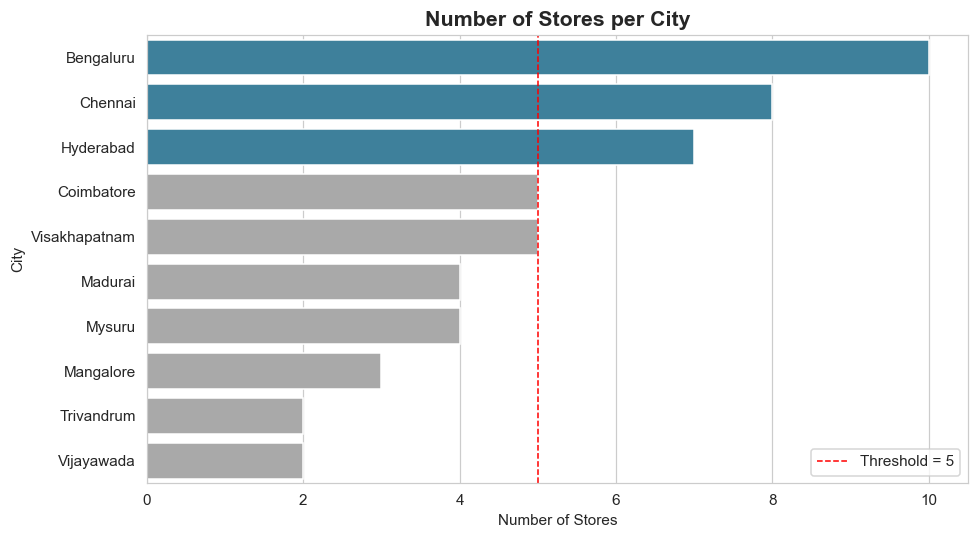

In [18]:
store_counts = stores.groupby('city')['store_id'].nunique().sort_values(ascending=False)
colors = ['#2E86AB' if v > 5 else '#A9A9A9' for v in store_counts.values]

plt.figure(figsize=(9, 5))
sns.barplot(x=store_counts.values, y=store_counts.index, palette=colors, hue=store_counts.index, legend=False)
plt.axvline(5, color='red', linestyle='--', linewidth=1, label='Threshold = 5')
plt.title('Number of Stores per City', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stores'); plt.ylabel('City')
plt.legend(); plt.tight_layout(); plt.show()

### 9.3 Average Base Price by Category

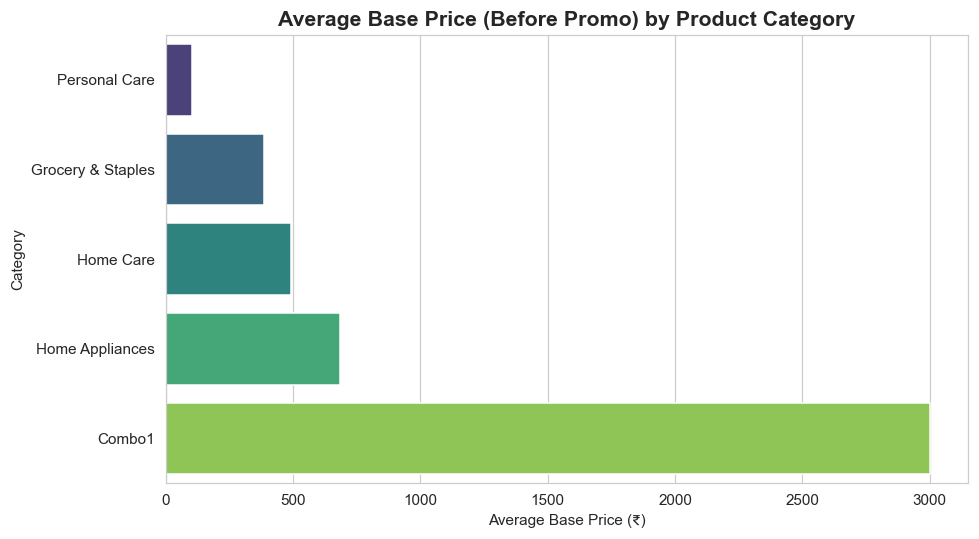

In [19]:
avg_price = events.groupby('category')['base_price(before_promo)'].mean().sort_values()

plt.figure(figsize=(9, 5))
sns.barplot(x=avg_price.values, y=avg_price.index, palette='viridis', hue=avg_price.index, legend=False)
plt.title('Average Base Price (Before Promo) by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Base Price (₹)'); plt.ylabel('Category')
plt.tight_layout(); plt.show()

### 9.4 Quantity Sold Before vs After Promo — Diwali vs Sankranti

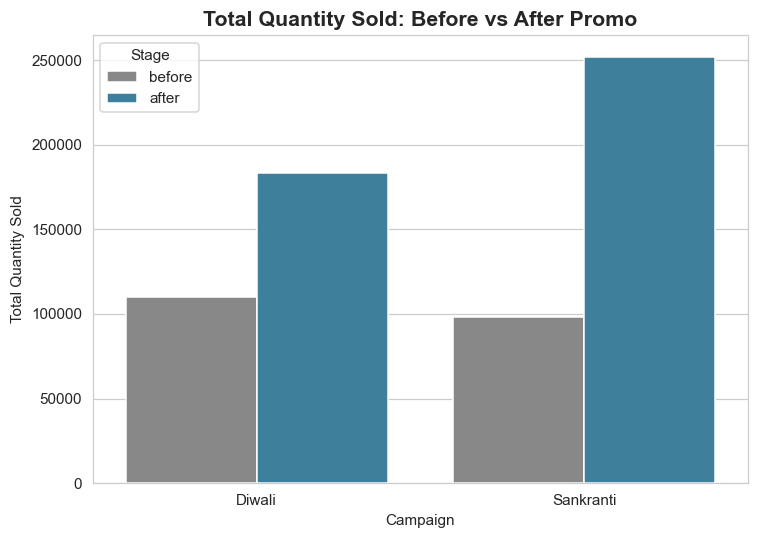

In [20]:
camp_compare = events[events['campaign_id'].isin([diwali_id, sankranti_id])].groupby('campaign_name').agg(
    before=('quantity_sold(before_promo)', 'sum'),
    after=('quantity_sold(after_promo)', 'sum')
).reset_index()
camp_melt = camp_compare.melt(id_vars='campaign_name', value_vars=['before', 'after'],
                               var_name='Stage', value_name='Quantity')

plt.figure(figsize=(7, 5))
sns.barplot(data=camp_melt, x='campaign_name', y='Quantity', hue='Stage', palette=['#888888', '#2E86AB'])
plt.title('Total Quantity Sold: Before vs After Promo', fontsize=14, fontweight='bold')
plt.xlabel('Campaign'); plt.ylabel('Total Quantity Sold')
plt.tight_layout(); plt.show()

### 9.5 Incremental Revenue % (IR%) by Product — Sankranti

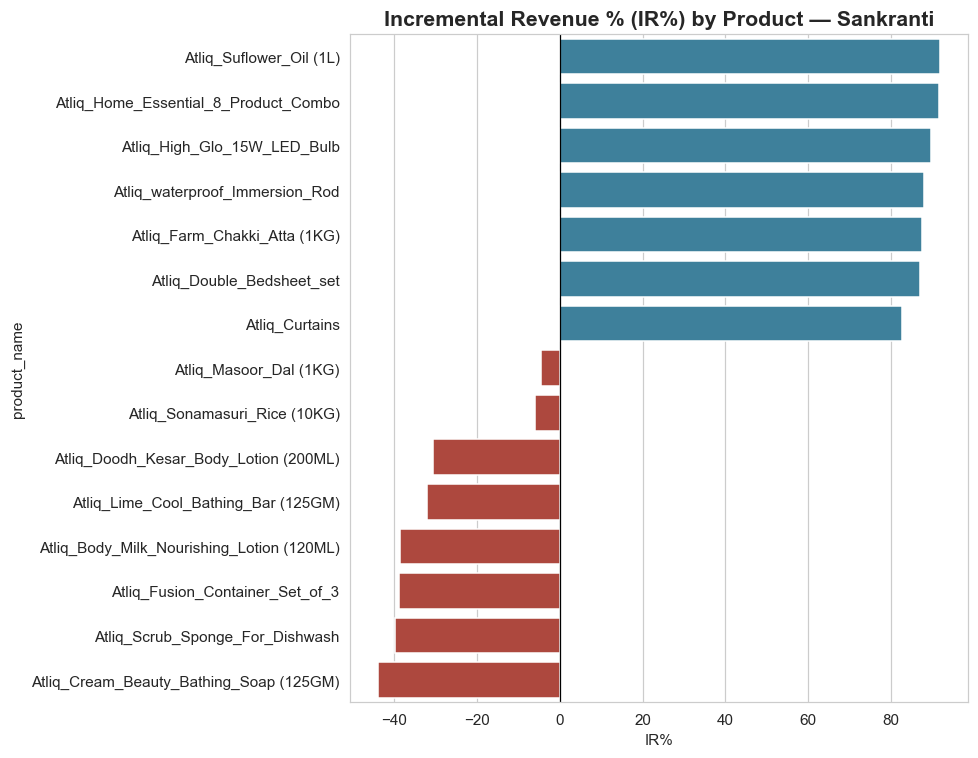

In [21]:
sankranti_events = events[events['campaign_id'] == sankranti_id]
product_rev = sankranti_events.groupby('product_name').agg(
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum')
).reset_index()
product_rev['IR%'] = (product_rev['revenue_after'] - product_rev['revenue_before']) / product_rev['revenue_before'] * 100
product_rev = product_rev.sort_values('IR%', ascending=False)

colors = ['#2E86AB' if v >= 0 else '#C0392B' for v in product_rev['IR%']]
plt.figure(figsize=(9, 7))
sns.barplot(data=product_rev, x='IR%', y='product_name', palette=colors, hue='product_name', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Incremental Revenue % (IR%) by Product — Sankranti', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 9.6 ISU% by Store — Visakhapatnam (Diwali)

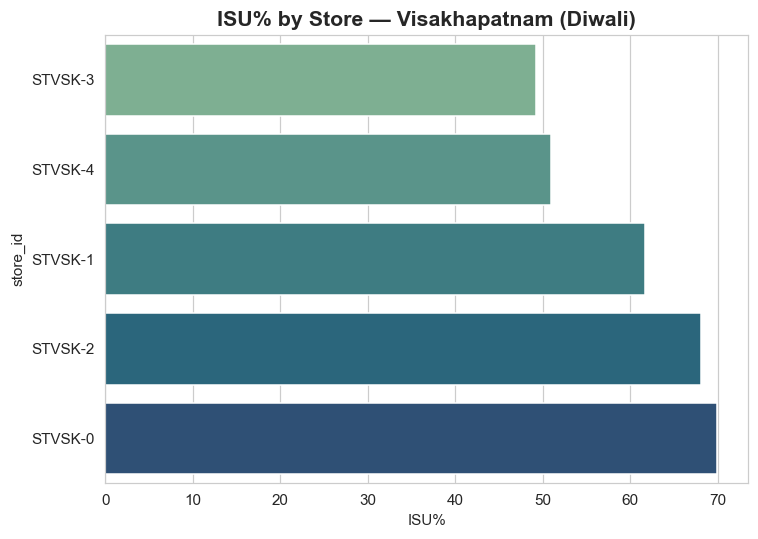

In [22]:
vsk_stores_list = stores[stores['city'] == 'Visakhapatnam']['store_id'].tolist()
diwali_vsk = events[(events['campaign_id'] == diwali_id) & (events['store_id'].isin(vsk_stores_list))]
store_agg = diwali_vsk.groupby('store_id').agg(
    qty_before=('quantity_sold(before_promo)', 'sum'),
    qty_after=('quantity_sold(after_promo)', 'sum')
).reset_index()
store_agg['ISU%'] = (store_agg['qty_after'] - store_agg['qty_before']) / store_agg['qty_before'] * 100
store_agg = store_agg.sort_values('ISU%')

plt.figure(figsize=(7, 5))
sns.barplot(data=store_agg, x='ISU%', y='store_id', palette='crest', hue='store_id', legend=False)
plt.title('ISU% by Store — Visakhapatnam (Diwali)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 9.7 IR% and ISU% by Promo Type — Sankranti

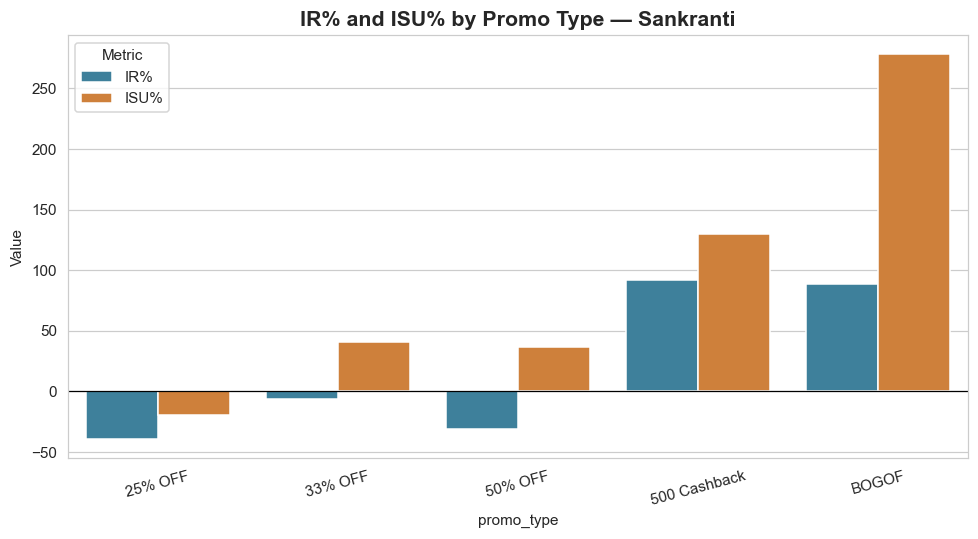

In [23]:
sankranti_promo = events[events['campaign_id'] == sankranti_id].groupby('promo_type').agg(
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum'),
    qty_before=('quantity_sold(before_promo)', 'sum'),
    qty_after=('quantity_sold(after_promo)', 'sum')
).reset_index()
sankranti_promo['IR%'] = (sankranti_promo['revenue_after'] - sankranti_promo['revenue_before']) / sankranti_promo['revenue_before'] * 100
sankranti_promo['ISU%'] = (sankranti_promo['qty_after'] - sankranti_promo['qty_before']) / sankranti_promo['qty_before'] * 100

promo_melt = sankranti_promo.melt(id_vars='promo_type', value_vars=['IR%', 'ISU%'], var_name='Metric', value_name='Value')

plt.figure(figsize=(9, 5))
sns.barplot(data=promo_melt, x='promo_type', y='Value', hue='Metric', palette=['#2E86AB', '#E67E22'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('IR% and ISU% by Promo Type — Sankranti', fontsize=14, fontweight='bold')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

---
## Summary

This analysis walked through data quality checks, cleaning, exploratory summaries, and campaign/store/promo-type level performance metrics (IR% and ISU%), supported by visual comparisons above.